In [2]:
pip install matplotlib

You should consider upgrading via the 'c:\Users\ACER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

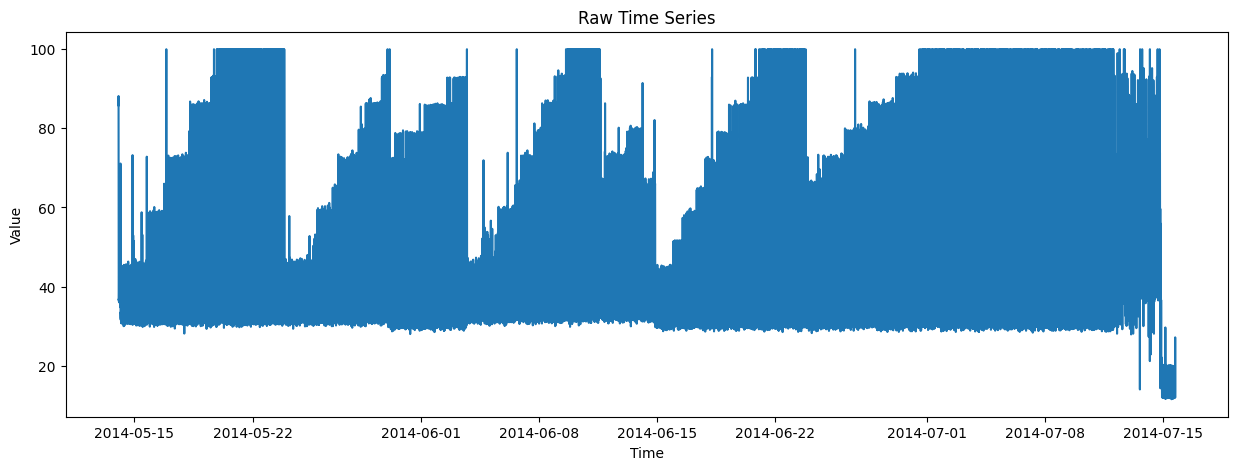

In [4]:
df = pd.read_csv("resource/cpu_utilization_asg_misconfiguration.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

plt.figure(figsize=(15,5))
plt.plot(df["timestamp"], df["value"])
plt.title("Raw Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [5]:
from scipy.stats import skew

data = df["value"]

print("Mean:", data.mean())
print("Std:", data.std())
print("Min:", data.min())
print("Max:", data.max())
print("Skewness:", skew(data))

Mean: 38.2827560498615
Std: 15.639293830231871
Min: 11.529000000000002
Max: 100.0
Skewness: 2.4170271033548985


In [6]:
%pip install seaborn statsmodels

You should consider upgrading via the 'c:\Users\ACER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


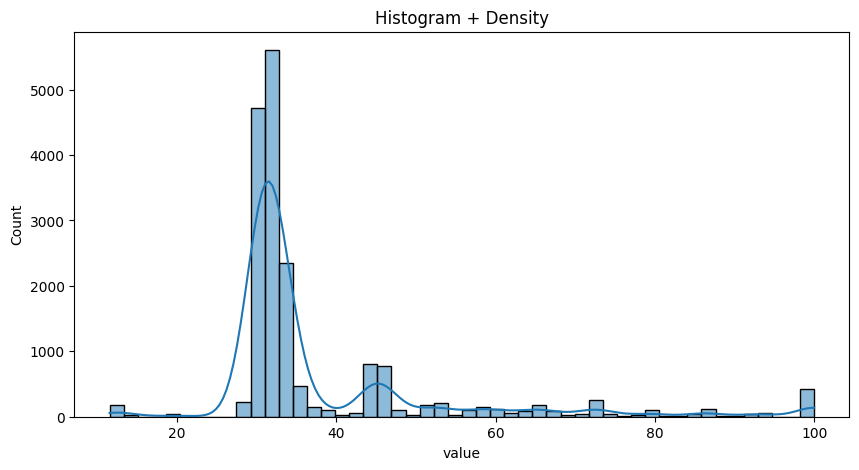

In [7]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    data,
    kde=True,
    bins=50
)

plt.title("Histogram + Density")
plt.show()

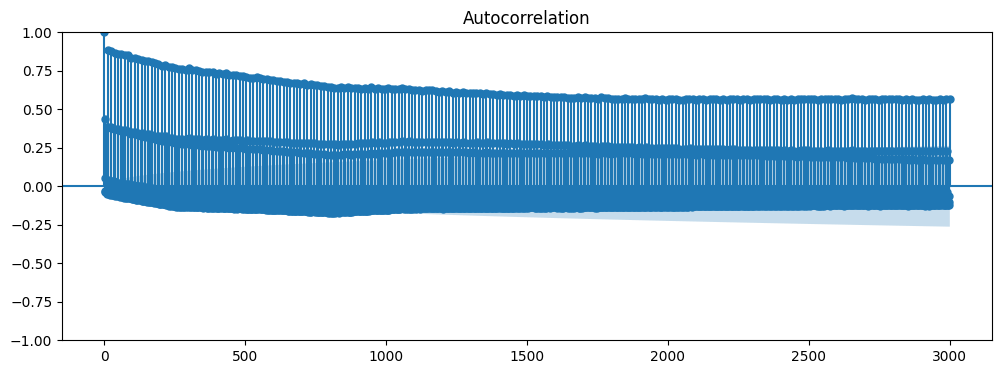

In [10]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(data, lags=3000, ax=ax)
plt.show()
# Peak đầu tiên (sau lag=0) = period
# VD: data 1-minute, peak ở lag 1440 → period = 1440 (daily pattern) ✓
# VD: data 1-minute, peak ở lag 10080 → period = 10080 (weekly pattern)


In [9]:
import json, pandas as pd
windows = json.load(open('resource/combined_labels.json'))
my_windows = windows['realKnownCause/cpu_utilization_asg_misconfiguration.csv']
# VD: [['2013-12-10 06:25:00', '2013-12-12 05:35:00'], ...]

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['is_anomaly'] = False
for start, end in my_windows:
    mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
    df.loc[mask, 'is_anomaly'] = True
print(f"Anomaly rows: {df['is_anomaly'].sum()} / {len(df)}")


Anomaly rows: 1499 / 18050


Right-skewed distribution (lệch phải). ko phải Gaussian. Không có seasonal. Non-stationar

In [15]:
df.head()

,timestamp,value
0,2014-05-14 01:14:00,85.835
1,2014-05-14 01:19:00,88.167
2,2014-05-14 01:24:00,44.595
3,2014-05-14 01:29:00,56.282
4,2014-05-14 01:34:00,36.534


In [17]:
import json

with open("resource/combined_labels.json", "r") as f:
    labels = json.load(f)

print(labels.keys())

dict_keys(['artificialNoAnomaly/art_daily_no_noise.csv', 'artificialNoAnomaly/art_daily_perfect_square_wave.csv', 'artificialNoAnomaly/art_daily_small_noise.csv', 'artificialNoAnomaly/art_flatline.csv', 'artificialNoAnomaly/art_noisy.csv', 'artificialWithAnomaly/art_daily_flatmiddle.csv', 'artificialWithAnomaly/art_daily_jumpsdown.csv', 'artificialWithAnomaly/art_daily_jumpsup.csv', 'artificialWithAnomaly/art_daily_nojump.csv', 'artificialWithAnomaly/art_increase_spike_density.csv', 'artificialWithAnomaly/art_load_balancer_spikes.csv', 'realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv', 'realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv', 'realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv', 'realAWSCloudwatch/ec2_cpu_utilization_77c1ca.csv', 'realAWSCloudwatch/ec2_cpu_utilization_825cc2.csv', 'realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv', 'realAWSCloudwatch/ec2_cpu_utilization_c6585a.csv', 'realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv', 'realAWSCloudwatch/ec2_disk_write_bytes_1e

In [13]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["iqr_anomaly"] = ((df["value"] < lower) | (df["value"] > upper)).astype(int)

print("IQR lower:", lower)
print("IQR upper:", upper)

precision_iqr = precision_score(df["is_anomaly"].astype(int), df["iqr_anomaly"])
recall_iqr = recall_score(df["is_anomaly"].astype(int), df["iqr_anomaly"])
f1_iqr = f1_score(df["is_anomaly"].astype(int), df["iqr_anomaly"])

print("IQR Precision:", precision_iqr)
print("IQR Recall:", recall_iqr)
print("IQR F1:", f1_iqr)

IQR lower: 23.481750000000005
IQR upper: 42.967749999999995
IQR Precision: 0.2356818181818182
IQR Recall: 0.6917945296864576
IQR F1: 0.3515850144092219


In [14]:
def build_features(df, window=60):
    s = df["value"]

    features = pd.DataFrame({
        "value": s,
        "rolling_mean_1h": s.rolling(window).mean(),
        "rolling_std_1h": s.rolling(window).std(),
        "rolling_mean_4h": s.rolling(window * 4).mean(),
        "rate_of_change": s.diff(),
        "rate_of_change_5m": s.diff(5),
        "lag_1": s.shift(1),
        "lag_60": s.shift(window),
        "hour": df["timestamp"].dt.hour,
        "dayofweek": df["timestamp"].dt.dayofweek,
        "z_score": (s - s.rolling(window).mean()) / s.rolling(window).std().replace(0, 1e-10),
    })

    return features.dropna()

X = build_features(df, window=60)

X.head()

,value,rolling_mean_1h,rolling_std_1h,rolling_mean_4h,rate_of_change,rate_of_change_5m,lag_1,lag_60,hour,dayofweek,z_score
239,46.336,33.647933,4.403835,34.793242,0.449,14.355,45.887,41.000,21,2,2.881140
240,73.229,34.343483,6.736235,34.740717,26.893,41.888,46.336,31.496,21,2,5.772589
241,59.539,34.809917,7.468815,34.621433,-13.690,28.771,73.229,31.553,21,2,3.310978
242,30.318,34.795783,7.476625,34.561946,-29.221,-4.367,59.539,31.166,21,2,-0.598904
243,33.280,34.809533,7.473005,34.466104,2.962,-12.607,30.318,32.455,21,2,-0.204674


In [15]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

for contamination in [0.01, 0.02, 0.05]:
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )

    model.fit(X)

    pred = model.predict(X)
    y_pred = (pred == -1).astype(int)

    y_true_aligned = df.loc[X.index, "is_anomaly"].astype(int).values

    precision = precision_score(y_true_aligned, y_pred)
    recall = recall_score(y_true_aligned, y_pred)
    f1 = f1_score(y_true_aligned, y_pred)

    results.append({
        "contamination": contamination,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

results_df = pd.DataFrame(results)
results_df

,contamination,precision,recall,f1
0,0.01,0.865922,0.103402,0.184744
1,0.02,0.717087,0.170781,0.275862
2,0.05,0.558923,0.332221,0.416736


In [34]:
import pickle

with open("isolation_forest_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as isolation_forest_model.pkl")

Model saved as isolation_forest_model.pkl


In [35]:
import os

print(os.path.exists("isolation_forest_model.pkl"))
print(f"Size: {os.path.getsize('isolation_forest_model.pkl')/1024:.2f} KB")

True
Size: 2171.72 KB


In [16]:
best_row = results_df.sort_values("f1", ascending=False).iloc[0]
best_contamination = best_row["contamination"]

print("Best contamination:", best_contamination)

best_model = IsolationForest(
    n_estimators=200,
    contamination=best_contamination,
    random_state=42
)

best_model.fit(X)

df["iforest_anomaly"] = 0
df.loc[X.index, "iforest_anomaly"] = (best_model.predict(X) == -1).astype(int)

best_row

Best contamination: 0.05


contamination    0.050000
precision        0.558923
recall           0.332221
f1               0.416736
Name: 2, dtype: float64

In [17]:
comparison = pd.DataFrame([
    {
        "detector": "IQR",
        "precision": precision_score(df["is_anomaly"].astype(int), df["iqr_anomaly"]),
        "recall": recall_score(df["is_anomaly"].astype(int), df["iqr_anomaly"]),
        "f1": f1_score(df["is_anomaly"].astype(int), df["iqr_anomaly"])
    },
    {
        "detector": f"Isolation Forest ({best_contamination})",
        "precision": precision_score(df["is_anomaly"].astype(int), df["iforest_anomaly"]),
        "recall": recall_score(df["is_anomaly"].astype(int), df["iforest_anomaly"]),
        "f1": f1_score(df["is_anomaly"].astype(int), df["iforest_anomaly"])
    }
])

comparison

,detector,precision,recall,f1
0,IQR,0.235682,0.691795,0.351585
1,Isolation Forest (0.05),0.558923,0.332221,0.416736


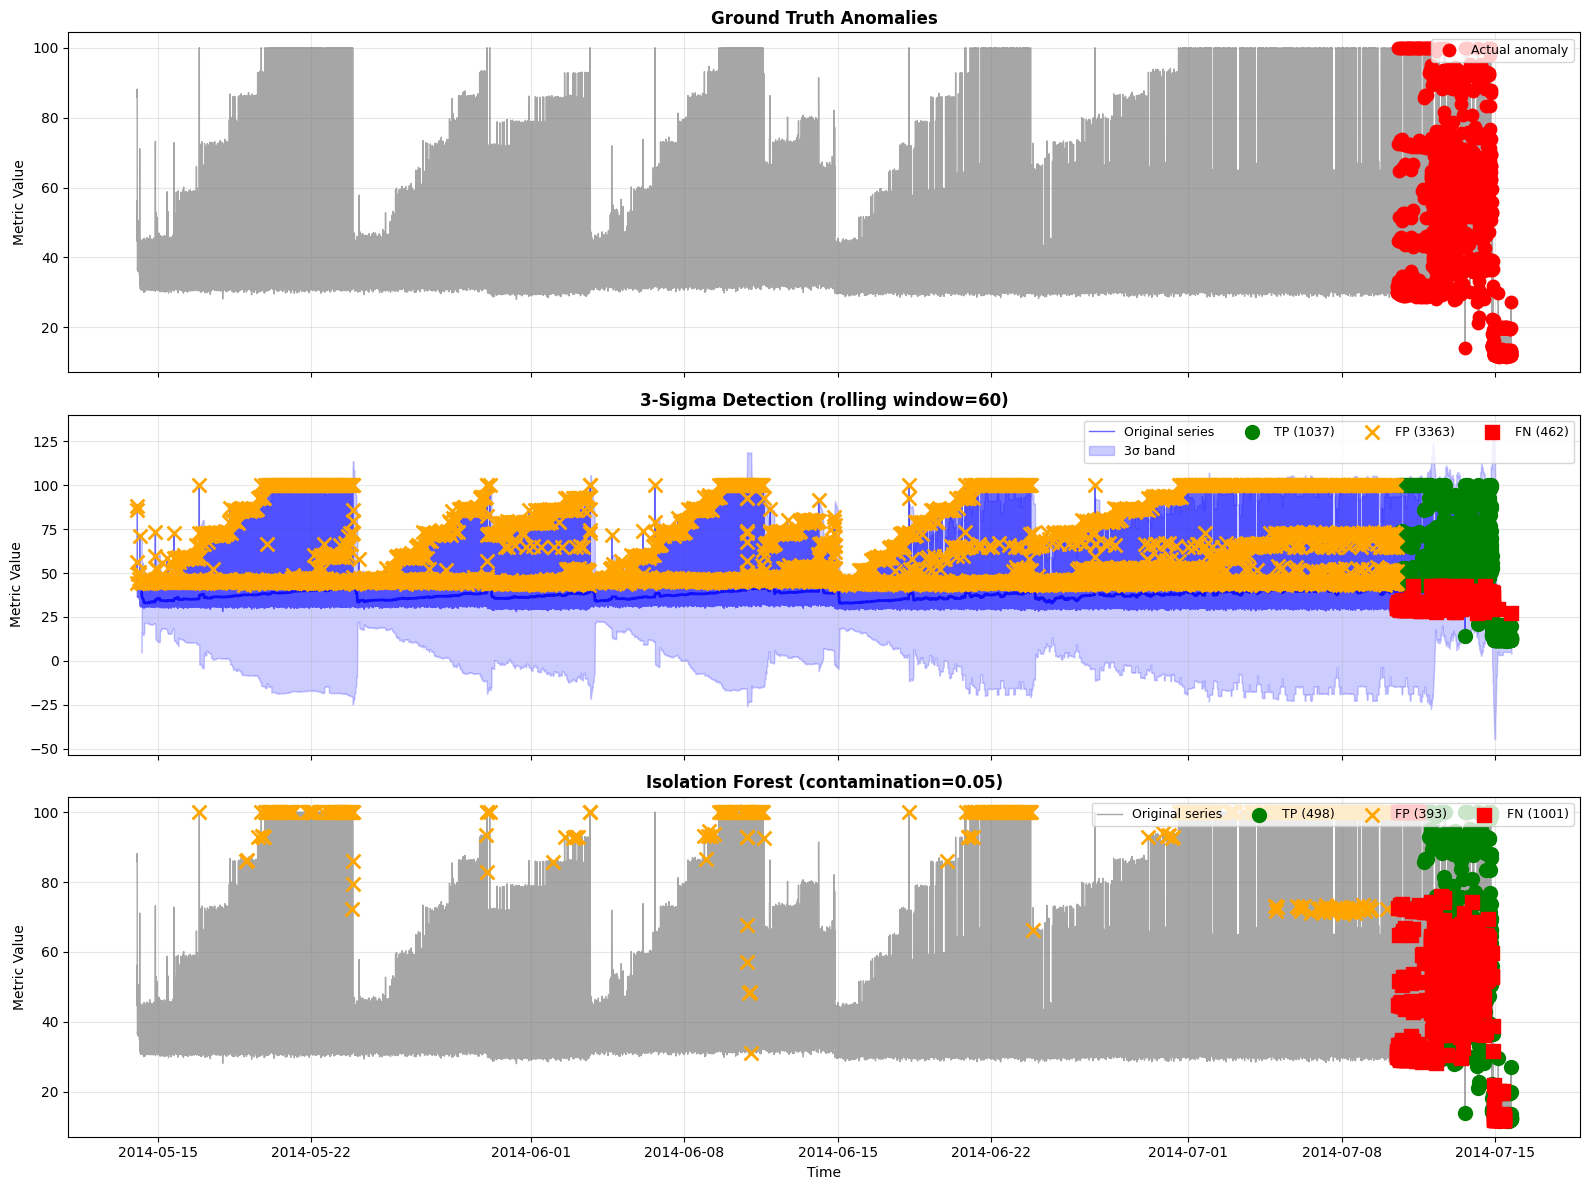

In [20]:
from sklearn.metrics import confusion_matrix

# Tính TP, FP, FN cho IQR
tn_iqr, fp_iqr, fn_iqr, tp_iqr = confusion_matrix(df["is_anomaly"].astype(int), df["iqr_anomaly"]).ravel()

# Tính TP, FP, FN cho Isolation Forest
tn_if, fp_if, fn_if, tp_if = confusion_matrix(df["is_anomaly"].astype(int), df["iforest_anomaly"]).ravel()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Subplot 1: Ground Truth Anomalies
axes[0].plot(df["timestamp"], df["value"], color="gray", alpha=0.7, linewidth=1)
axes[0].scatter(
    df.loc[df["is_anomaly"], "timestamp"],
    df.loc[df["is_anomaly"], "value"],
    color="red",
    s=80,
    marker="o",
    label="Actual anomaly",
    zorder=5
)
axes[0].set_title("Ground Truth Anomalies", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Metric Value", fontsize=10)
axes[0].legend(loc="upper right", fontsize=9)
axes[0].grid(True, alpha=0.3)

# Subplot 2: IQR Detection (rolling window=60)
rolling_mean = df["value"].rolling(window=60).mean()
rolling_std = df["value"].rolling(window=60).std()
upper_band = rolling_mean + 3 * rolling_std
lower_band = rolling_mean - 3 * rolling_std

axes[1].plot(df["timestamp"], df["value"], color="blue", alpha=0.6, linewidth=1, label="Original series")
axes[1].fill_between(df["timestamp"], lower_band, upper_band, alpha=0.2, color="blue", label="3σ band")
axes[1].plot(df["timestamp"], rolling_mean, color="blue", linewidth=2, alpha=0.8)

# TP: predicted=1, actual=1 (xanh)
tp_iqr_mask = (df["iqr_anomaly"] == 1) & (df["is_anomaly"] == True)
axes[1].scatter(
    df.loc[tp_iqr_mask, "timestamp"],
    df.loc[tp_iqr_mask, "value"],
    color="green",
    s=100,
    marker="o",
    label=f"TP ({tp_iqr})",
    zorder=5
)

# FP: predicted=1, actual=0 (cam)
fp_iqr_mask = (df["iqr_anomaly"] == 1) & (df["is_anomaly"] == False)
axes[1].scatter(
    df.loc[fp_iqr_mask, "timestamp"],
    df.loc[fp_iqr_mask, "value"],
    color="orange",
    s=100,
    marker="x",
    linewidths=2,
    label=f"FP ({fp_iqr})",
    zorder=5
)

# FN: predicted=0, actual=1 (đỏ)
fn_iqr_mask = (df["iqr_anomaly"] == 0) & (df["is_anomaly"] == True)
axes[1].scatter(
    df.loc[fn_iqr_mask, "timestamp"],
    df.loc[fn_iqr_mask, "value"],
    color="red",
    s=100,
    marker="s",
    label=f"FN ({fn_iqr})",
    zorder=5
)

axes[1].set_title(f"3-Sigma Detection (rolling window=60)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Metric Value", fontsize=10)
axes[1].legend(loc="upper right", fontsize=9, ncol=4)
axes[1].grid(True, alpha=0.3)

# Subplot 3: Isolation Forest
axes[2].plot(df["timestamp"], df["value"], color="gray", alpha=0.7, linewidth=1, label="Original series")

# TP: predicted=1, actual=1 (xanh)
tp_if_mask = (df["iforest_anomaly"] == 1) & (df["is_anomaly"] == True)
axes[2].scatter(
    df.loc[tp_if_mask, "timestamp"],
    df.loc[tp_if_mask, "value"],
    color="green",
    s=100,
    marker="o",
    label=f"TP ({tp_if})",
    zorder=5
)

# FP: predicted=1, actual=0 (cam)
fp_if_mask = (df["iforest_anomaly"] == 1) & (df["is_anomaly"] == False)
axes[2].scatter(
    df.loc[fp_if_mask, "timestamp"],
    df.loc[fp_if_mask, "value"],
    color="orange",
    s=100,
    marker="x",
    linewidths=2,
    label=f"FP ({fp_if})",
    zorder=5
)

# FN: predicted=0, actual=1 (đỏ)
fn_if_mask = (df["iforest_anomaly"] == 0) & (df["is_anomaly"] == True)
axes[2].scatter(
    df.loc[fn_if_mask, "timestamp"],
    df.loc[fn_if_mask, "value"],
    color="red",
    s=100,
    marker="s",
    label=f"FN ({fn_if})",
    zorder=5
)

axes[2].set_title(f"Isolation Forest (contamination={best_contamination})", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Time", fontsize=10)
axes[2].set_ylabel("Metric Value", fontsize=10)
axes[2].legend(loc="upper right", fontsize=9, ncol=4)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

iqr_results = []

for multiplier in [1.0, 1.5, 2.0]:

    Q1 = np.percentile(df["value"], 25)
    Q3 = np.percentile(df["value"], 75)

    IQR = Q3 - Q1

    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR

    pred = (
        (df["value"] < lower) |
        (df["value"] > upper)
    ).astype(int)

    precision = precision_score(df["is_anomaly"].astype(int), pred)
    recall = recall_score(df["is_anomaly"].astype(int), pred)
    f1 = f1_score(df["is_anomaly"].astype(int), pred)

    tn, fp, fn, tp = confusion_matrix(df["is_anomaly"].astype(int), pred).ravel()

    iqr_results.append({
        "method": f"IQR ({multiplier})",
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarms": fp
    })

iqr_results = pd.DataFrame(iqr_results)

iqr_results

,method,precision,recall,f1,false_alarms
0,IQR (1.0),0.236409,0.699133,0.353338,3385
1,IQR (1.5),0.235682,0.691795,0.351585,3363
2,IQR (2.0),0.290169,0.651768,0.401562,2390


In [22]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix

if_results = []

for contamination in [0.01, 0.02, 0.05]:

    clf = IsolationForest(
        contamination=contamination,
        n_estimators=200,
        random_state=42
    )

    clf.fit(X)

    pred = (clf.predict(X) == -1).astype(int)

    y_true_aligned = df["is_anomaly"].iloc[X.index].astype(int).values

    precision = precision_score(y_true_aligned, pred)
    recall = recall_score(y_true_aligned, pred)
    f1 = f1_score(y_true_aligned, pred)

    tn, fp, fn, tp = confusion_matrix(
        y_true_aligned,
        pred
    ).ravel()

    if_results.append({
        "method": f"IF ({contamination})",
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarms": fp
    })

if_results = pd.DataFrame(if_results)

if_results

,method,precision,recall,f1,false_alarms
0,IF (0.01),0.865922,0.103402,0.184744,24
1,IF (0.02),0.717087,0.170781,0.275862,101
2,IF (0.05),0.558923,0.332221,0.416736,393


In [31]:
best_iqr = iqr_results.sort_values(
    "f1",
    ascending=False
).iloc[0]

best_if = if_results.sort_values(
    "f1",
    ascending=False
).iloc[0]

In [32]:
comparison = pd.DataFrame([
    {
        "Metric": "Precision",
        "Detector 1 (IQR)": round(best_iqr["precision"],3),
        "Detector 2 (IF)": round(best_if["precision"],3)
    },
    {
        "Metric": "Recall",
        "Detector 1 (IQR)": round(best_iqr["recall"],3),
        "Detector 2 (IF)": round(best_if["recall"],3)
    },
    {
        "Metric": "F1",
        "Detector 1 (IQR)": round(best_iqr["f1"],3),
        "Detector 2 (IF)": round(best_if["f1"],3)
    },
    {
        "Metric": "False Alarms",
        "Detector 1 (IQR)": int(best_iqr["false_alarms"]),
        "Detector 2 (IF)": int(best_if["false_alarms"])
    }
])

comparison

,Metric,Detector 1 (IQR),Detector 2 (IF)
0,Precision,0.195,0.378
1,Recall,0.808,0.415
2,F1,0.314,0.396
3,False Alarms,2710.000,554.000
